# Titanic Survival Analysis
### Exploratory Data Analysis + a simple Machine Learning model

**Goal:** Analyze real passenger data from the Titanic (1912) to understand which
factors — gender, class, age, fare — most influenced whether a passenger survived,
and build a simple model to predict survival.

**Dataset:** 891 passengers, 12 features (public dataset, widely used for data science practice).

**Tools used:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn


In [1]:
# Basic libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make charts look clean
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load and inspect the data

In [2]:
df = pd.read_csv('data/titanic.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Data types and missing values overview
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Count of missing values per column
df.isnull().sum().sort_values(ascending=False)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

**Observation:** `Cabin` is missing for most passengers (too incomplete to use
reliably), `Age` has some missing values we can fill in, and `Embarked` has just
a couple of missing entries.

## 2. Clean the data

In [5]:
# Fill missing Age with the median age (robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin (too many missing values) and columns that don't help analysis
df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

# Confirm no more missing values in the columns we care about
df.isnull().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## 3. Exploratory Data Analysis

### 3.1 Overall survival rate

Overall survival rate: 38.4%


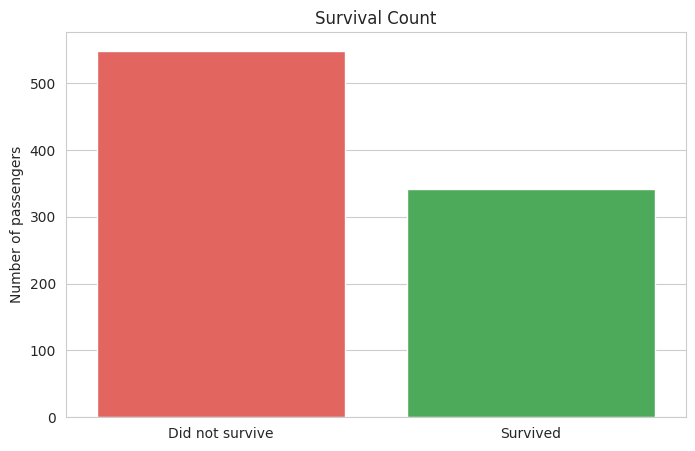

In [6]:
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

sns.countplot(data=df, x='Survived', hue='Survived', palette=['#f85149', '#3fb950'], legend=False)
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.title('Survival Count')
plt.ylabel('Number of passengers')
plt.xlabel('')
plt.savefig('images/01_survival_count.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.2 Survival by gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


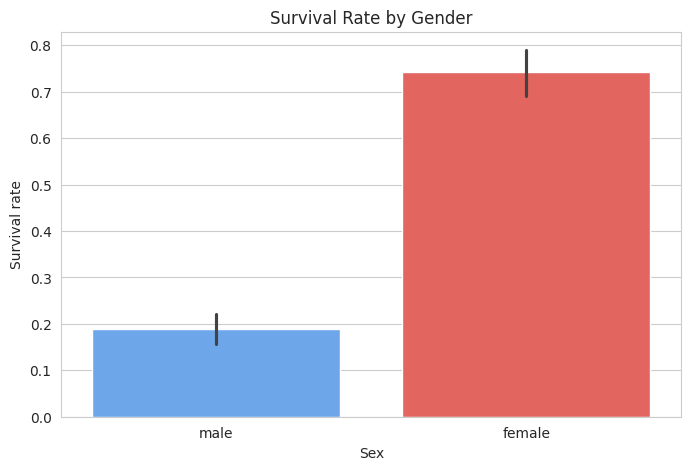

In [7]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print(gender_survival)

sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette=['#58a6ff', '#f85149'], legend=False)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival rate')
plt.savefig('images/02_survival_by_gender.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight:** Women had a dramatically higher survival rate than men — consistent
with the "women and children first" evacuation policy used on the Titanic.

### 3.3 Survival by passenger class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


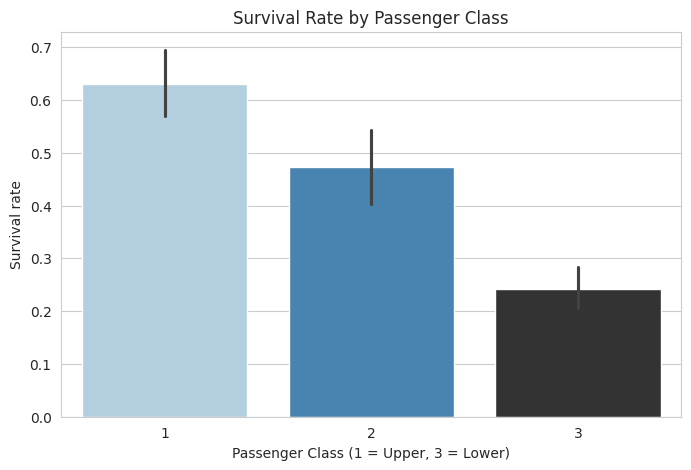

In [8]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print(class_survival)

sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='Blues_d', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = Upper, 3 = Lower)')
plt.ylabel('Survival rate')
plt.savefig('images/03_survival_by_class.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight:** 1st class passengers survived at a much higher rate than 3rd class —
likely due to cabin location (closer to lifeboats) and priority during evacuation.

### 3.4 Age distribution: survivors vs non-survivors

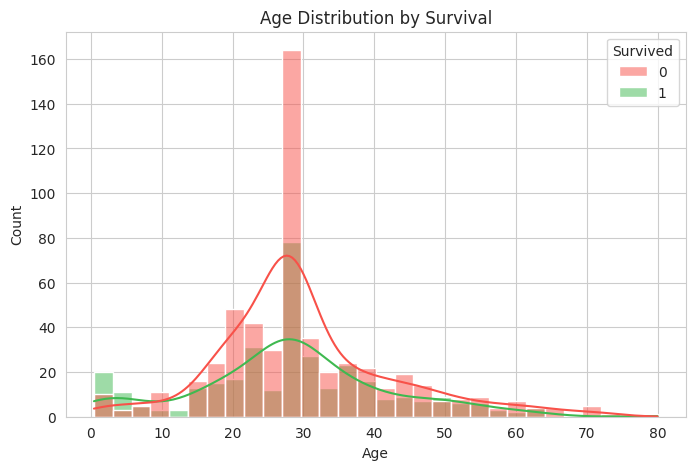

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette=['#f85149', '#3fb950'])
plt.title('Age Distribution by Survival')
plt.savefig('images/04_age_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight:** Young children had a noticeably better survival rate, which again
lines up with the evacuation priority given to children.

### 3.5 Survival by embarkation port

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


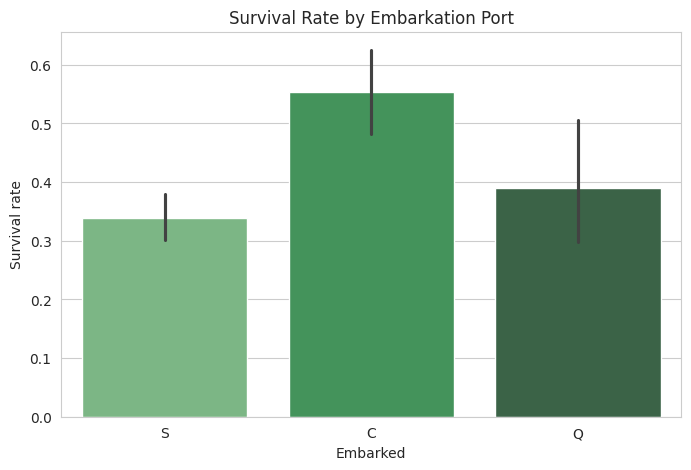

In [10]:
port_survival = df.groupby('Embarked')['Survived'].mean() * 100
print(port_survival)

sns.barplot(data=df, x='Embarked', y='Survived', hue='Embarked', palette='Greens_d', legend=False)
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival rate')
plt.savefig('images/05_survival_by_port.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.6 Correlation heatmap

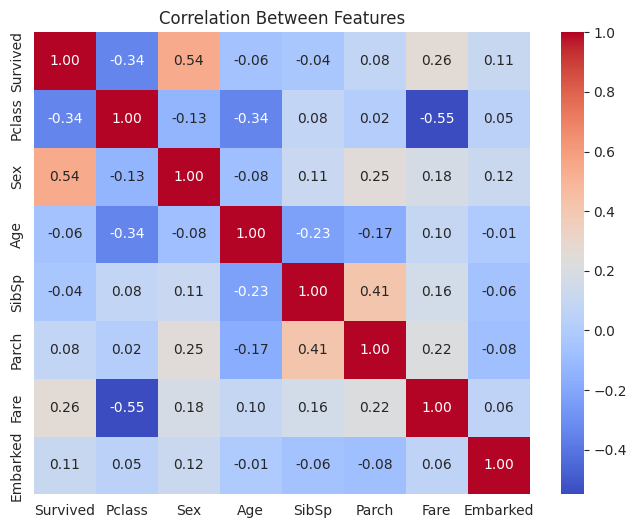

In [11]:
# Convert categorical columns to numbers so we can compute correlation
df_corr = df.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Features')
plt.savefig('images/06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight:** `Sex` and `Fare` have the strongest correlation with survival —
confirming gender and class/wealth were the two biggest survival factors.

## 4. Predicting survival with a simple ML model

Now that we understand the data, let's build a basic **Logistic Regression** model to predict whether a passenger survived, based on the features we explored above.

In [12]:
# Prepare features (X) and target (y)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_corr[features]
y = df_corr['Survived']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 712
Testing samples: 179


In [13]:
# Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy * 100:.1f}%")


Model accuracy: 79.9%


In [14]:
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


                 precision    recall  f1-score   support

Did not survive       0.82      0.85      0.83       105
       Survived       0.77      0.73      0.75        74

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



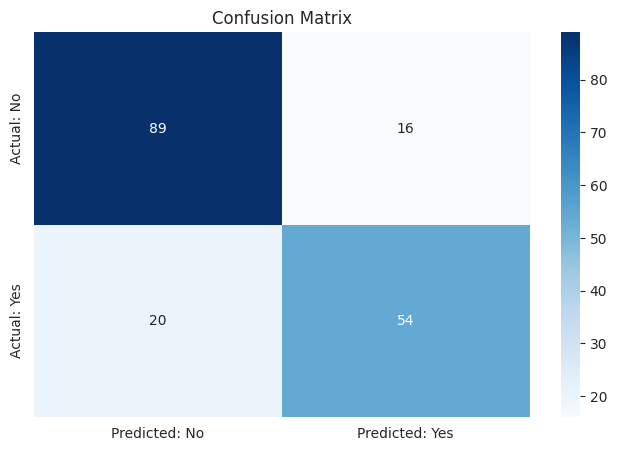

In [15]:
# Confusion matrix - shows correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix')
plt.savefig('images/07_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


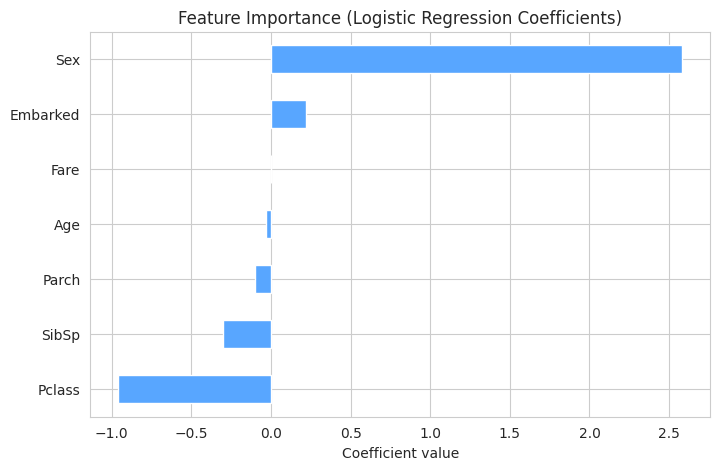

In [16]:
# Which features mattered most to the model?
importance = pd.Series(model.coef_[0], index=features).sort_values()
importance.plot(kind='barh', color='#58a6ff')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient value')
plt.savefig('images/08_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Conclusion

**Key findings:**
- Overall survival rate on the Titanic was about **38%**
- **Gender** was the single biggest survival factor — women survived at a far higher rate than men
- **Passenger class** mattered a lot — 1st class passengers survived far more often than 3rd class
- **Age** played a role too — younger children had better survival odds
- A simple Logistic Regression model using just 7 features predicted survival with reasonable accuracy on unseen data

**Possible next steps:**
- Try other models (Random Forest, XGBoost) to compare accuracy
- Engineer new features (e.g., family size = SibSp + Parch)
- Tune hyperparameters for better performance
